In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("rushilprajapati/data-final")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 2.32G/2.32G [02:00<00:00, 20.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rushilprajapati/data-final/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/rushilprajapati/data-final/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/rushilprajapati/data-final/versions/1):
['data']


In [ ]:
import os

# Path to 'data' folder
data_folder_path = os.path.join(path, 'data')

if os.path.exists(data_folder_path):
    contents = os.listdir(data_folder_path)
    print(f"Contents in 'data' folder ({data_folder_path}):")
    display(contents)

    # Deeper check for subdirectories
    for item in contents[:5]: # Check the first 5 items
        item_path = os.path.join(data_folder_path, item)
        if os.path.isdir(item_path):
            print(f"\nSubfolder '{item}' contains: {os.listdir(item_path)[:10]}...")
else:
    print("Data folder not found.")

Contents in 'data' folder (/root/.cache/kagglehub/datasets/rushilprajapati/data-final/versions/1/data):


['Non-scientific',
 'Macroscopy',
 'FACS',
 'Microscopy',
 'Histopathology',
 'Blot-Gel']


Subfolder 'Non-scientific' contains: ['image_5959.jpg', 'image_1880.jpg', 'image_851.jpg', 'image_5771.jpg', 'image_5737.jpg', 'image_791.jpg', 'image_4162.jpg', 'image_2744.jpg', 'image_900.jpg', 'image_5508.jpg']...

Subfolder 'Macroscopy' contains: ['ISIC_0026923.jpg', 'NORMAL2-IM-0807-0001.jpeg', '050103.png', '91b51883-f013-4844-bb89-58e3fdf52621.jpg', 'a89f9bb4-7ade-49cf-91aa-31eb2d218226.jpg', 'c1d280f4-18fb-4d2e-a361-9787ea093e6f.jpg', 'ISIC_0027435.jpg', 'e20b3577-81fd-4769-8d46-6ed02727ffa2.jpg', '1-3-46-670589-33-1-63716506118773221000001-5491402665325019197_png_jpg.rf.1d5d457a46fef3973127a1618f75d693.jpg', '050306.png']...

Subfolder 'FACS' contains: ['050103.png', '030107 (3).png', '060102 (7).png', '040004 (7).png', '020002 (7).png', '030003 (10).png', '010102 (2).png', '060107 (2).png', '040000 (16).png', '030001 (8).png']...

Subfolder 'Microscopy' contains: ['050103.png', '050002 (14).png', '050306.png', '040004 (7).png', '020002 (7).png', '010040.png', '060701.png', 

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Set source and destination paths
source_dir = data_folder_path
base_split_dir = '/content/dataset_split'
train_dir = os.path.join(base_split_dir, 'train')
test_dir = os.path.join(base_split_dir, 'test')

# Create train/test directories
for d in [train_dir, test_dir]:
    if not os.path.exists(d):
        os.makedirs(d)

# Get list of classes (subfolders in 'data')
classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

for cls in classes:
    cls_source_path = os.path.join(source_dir, cls)

    # Create subfolders for each class in train and test
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    # Get list of all image files
    images = [f for f in os.listdir(cls_source_path) if os.path.isfile(os.path.join(cls_source_path, f))]

    if len(images) > 0:
        # Split with 8/2 ratio
        train_imgs, test_imgs = train_test_split(images, test_size=0.2, random_state=42)

        # Copy files to respective directories
        for img in train_imgs:
            shutil.copy(os.path.join(cls_source_path, img), os.path.join(train_dir, cls, img))
        for img in test_imgs:
            shutil.copy(os.path.join(cls_source_path, img), os.path.join(test_dir, cls, img))

        print(f"Class '{cls}': {len(train_imgs)} train images, {len(test_imgs)} test images.")

print("\nDataset split completed at:", base_split_dir)

Class 'Non-scientific': 4008 train images, 1002 test images.
Class 'Macroscopy': 3569 train images, 893 test images.
Class 'FACS': 856 train images, 214 test images.
Class 'Microscopy': 1207 train images, 302 test images.
Class 'Histopathology': 4143 train images, 1036 test images.
Class 'Blot-Gel': 1500 train images, 375 test images.

Dataset split completed at: /content/dataset_split


In [ ]:
import tensorflow as tf

# Check if GPU is available
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found. Please enable GPU in Notebook Settings.')
else:
  print(f'Found GPU at: {device_name}')

# Print TensorFlow version
print(f'TensorFlow version: {tf.__version__}')

Found GPU at: /device:GPU:0
TensorFlow version: 2.20.0


In [ ]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers

# Set parameters
img_size = (224, 224)
batch_size = 32
num_classes = len(classes)

# Data Augmentation and Loading
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Build Model
with tf.device('/GPU:0'):
    base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze base model

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    # FIXED: Changed 'categorical_loss' to 'categorical_crossentropy'
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy' if num_classes > 2 else 'binary_crossentropy',
                  metrics=['accuracy'])

    # Train the model
    history = model.fit(
        train_generator,
        epochs=10,
        validation_data=validation_generator
    )

Found 15283 images belonging to 6 classes.
Found 3822 images belonging to 6 classes.
Epoch 1/10
478/478 ━━━━━━━━━━━━━━━━━━━━ 277s 548ms/step - accuracy: 0.9513 - loss: 0.1612 - val_accuracy: 0.9788 - val_loss: 0.0621
Epoch 2/10
478/478 ━━━━━━━━━━━━━━━━━━━━ 232s 485ms/step - accuracy: 0.9757 - loss: 0.0775 - val_accuracy: 0.9827 - val_loss: 0.0564
Epoch 3/10
478/478 ━━━━━━━━━━━━━━━━━━━━ 234s 489ms/step - accuracy: 0.9828 - loss: 0.0528 - val_accuracy: 0.9830 - val_loss: 0.0543
Epoch 4/10
478/478 ━━━━━━━━━━━━━━━━━━━━ 234s 489ms/step - accuracy: 0.9831 - loss: 0.0555 - val_accuracy: 0.9830 - val_loss: 0.0573
Epoch 5/10
478/478 ━━━━━━━━━━━━━━━━━━━━ 237s 495ms/step - accuracy: 0.9850 - loss: 0.0529 - val_accuracy: 0.9846 - val_loss: 0.0513
Epoch 6/10
478/478 ━━━━━━━━━━━━━━━━━━━━ 239s 500ms/step - accuracy: 0.9848 - loss: 0.0470 - val_accuracy: 0.9859 - val_loss: 0.0457
Epoch 7/10
478/478 ━━━━━━━━━━━━━━━━━━━━ 238s 497ms/step - accuracy: 0.9881 - loss: 0.0389 - val_accuracy: 0.9827 - val_loss

In [ ]:
# Summarize training results
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("--- Training Summary ---")
print(f"Final Training Accuracy:   {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss:       {final_train_loss:.4f}")
print(f"Final Validation Loss:     {final_val_loss:.4f}")

--- Training Summary ---
Final Training Accuracy:   0.9877
Final Validation Accuracy: 0.9887
Final Training Loss:       0.0445
Final Validation Loss:     0.0540


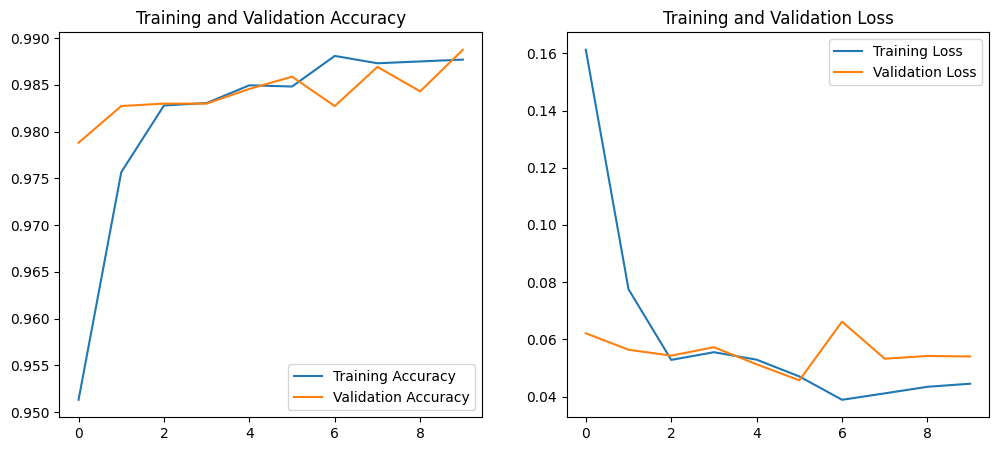

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy and loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.show()